<a href="https://colab.research.google.com/github/JCSR2022/Alura_Data_Science/blob/main/Flight_Delay_Prediction_Project/Optimizacion_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Project

We will be developing a Machine Learning model using Scikit-learn, with flight delay data from an airport contained in the file 'flights.csv'.

The goal of this project is to generate a model that allows us to accurately predict flight delays, thereby optimizing airport operations.

# 0.1 Libs

In [1]:
# -----------------------------
# Librerias
# -----------------------------

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from seaborn.palettes import color_palette
import yellowbrick
import random
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:

# -----------------------------
# Configuración visual global
#https://seaborn.pydata.org/tutorial/color_palettes.html
# -----------------------------


# -----------------------------
# Configuración visual global
# -----------------------------
sns.set_theme(style="white", font_scale=1.1)

color_palette_options = ["viridis","rocket","Blues","crest","flare","magma","rocket_r"]
curr_color = random.choice(color_palette_options)
curr_color = "crest"
CMAP = sns.color_palette(curr_color, as_cmap=True)

# rango visible del colormap (evita los tonos demasiado claros)
COLOR_MIN = 0.1
COLOR_MAX = 0.9
def value_to_color(v, vmin, vmax):
    norm = Normalize(vmin, vmax)
    return CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))


#style must be one of white, dark, whitegrid, darkgrid, ticks
sns.set_theme(
    style="whitegrid",        # limpio, sin grids pesados
    palette="rocket",         # colores
    font="sans-serif",
    font_scale=1.1
)
print(curr_color)

crest


In [4]:
#https://github.com/JCSR2022/Alura_Data_Science/blob/main/Flight_Delay_Prediction_Project/flights.csv

git_raw = 'https://raw.githubusercontent.com/'
url_github = 'JCSR2022/Alura_Data_Science/main/Flight_Delay_Prediction_Project/flights.csv'
datos = pd.read_csv(git_raw + url_github)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [6]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [7]:
datos

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271
...,...,...,...,...,...,...,...,...,...,...,...
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844


# Exploratory Data Analysis (EDA)

Data Quality: The dataset is robust with 71,175 records and 0 null values, facilitating the direct start of modeling.

Delay Behavior: * 25% of flights are not delayed, but rather depart early (up to -4.41 min).

The median (50%) is ~9.74 minutes, but the average is higher (12.5 min), indicating a distribution skewed by flights with critical delays.

There is an extreme maximum value of 125 minutes, which represents the main challenge for operational optimization.

Volatility: The standard deviation is 23 minutes, indicating high variability that justifies the use of advanced models such as Random Forest Regressor.

## Airline delays

In [8]:
# -----------------------------
# Tabla estilizada
# -----------------------------
def show_table(df, column=None):

    if column:
        df = df.sort_values(by=column, ascending=False)

        vmin = df[column].min()
        vmax = df[column].max()

        def style_cell(v):
            r, g, b, _ = value_to_color(v, vmin, vmax)
            return f'background-color: rgb({int(r*255)}, {int(g*255)}, {int(b*255)})'

        styled = df.style.applymap(style_cell, subset=[column])

    else:
        styled = df.style

    return (
        styled
        .format(precision=2)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("font-weight", "bold"),
                 ("text-align", "center")
             ]}
        ])
    )

# -----------------------------
# Barplot estandarizado
# -----------------------------
def barplot(df, x, y, title, y_unit=None, x_unit=None):

    df = df.sort_values(by=y, ascending=False)

    norm = Normalize(df[y].min(), df[y].max())

    colors = [ CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))for v in df[y] ]

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.bar(df[x], df[y], color=colors)

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax.set_ylabel(y + (f" [{y_unit}]" if y_unit else ""))

    # -------- agregar valores en cada barra --------
    offset = df[y].max() * 0.01

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

    sns.despine()
    plt.tight_layout()

    return fig

,airline,delay
1,MM,40.50
2,YE,25.77
0,BZ,3.08


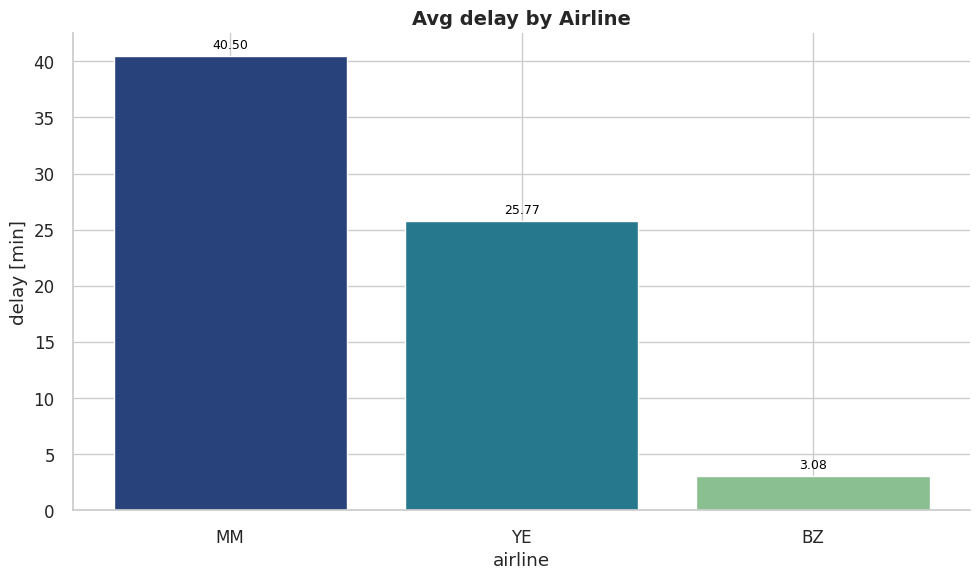

In [9]:
avg_delay_airline = datos.groupby('airline')['delay'].mean().reset_index()
display(show_table(avg_delay_airline, 'delay'))
barplot(avg_delay_airline, 'airline', 'delay', 'Avg delay by Airline','min').show()

,airline,flights
0,BZ,47598
1,YE,14137
2,MM,9440


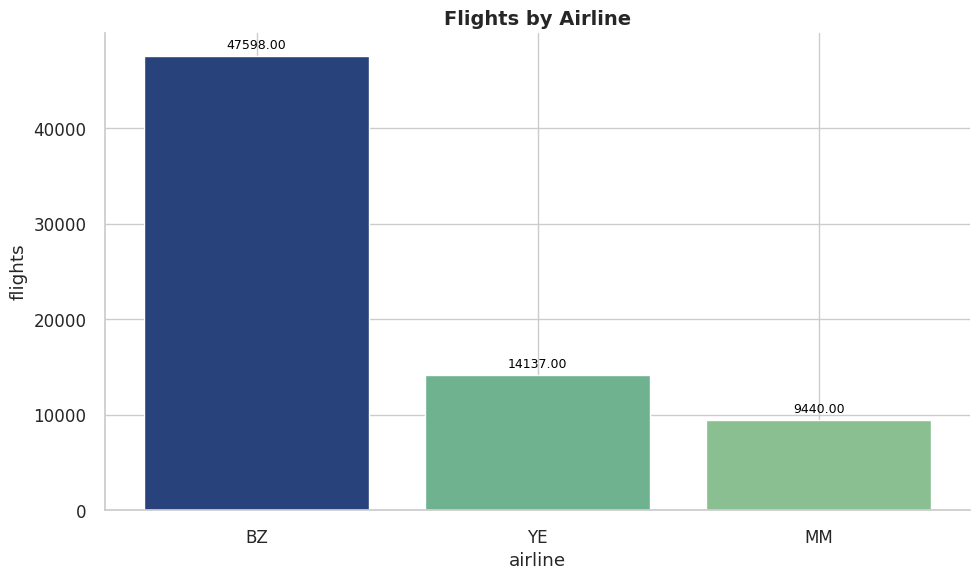

In [10]:
cnt_flights = datos.value_counts('airline').reset_index()
cnt_flights.rename(columns={'count':'flights'}, inplace=True)
display(show_table(cnt_flights, 'flights'))
barplot(cnt_flights, 'airline', 'flights', 'Flights by Airline').show()

,schengen,flights
0,schengen,42569
1,non-schengen,28606


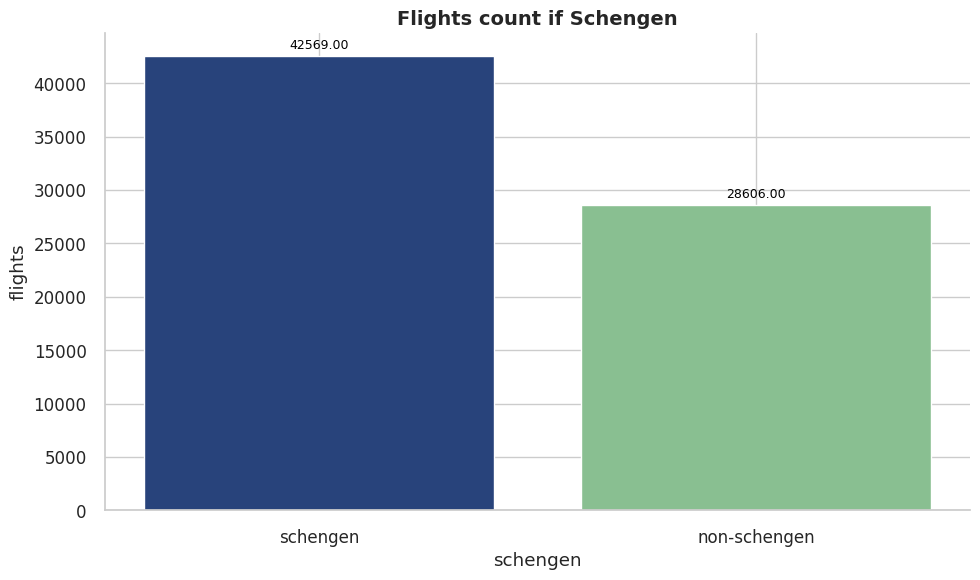

In [11]:
"""
The Schengen Area is a geographical area encompassing most European countries,
where border controls have been eliminated to allow the free movement of
people between member states. This area takes its name from the Schengen
Agreement, signed in 1985 in the village of Schengen, Luxembourg,
and implemented in 1995.

The agreement was named after the place of signing, but the Schengen
Treaty itself was a development of the 1990 Schengen Agreement.
"""

cnt_schengen = datos.value_counts('schengen').reset_index()
cnt_schengen.rename(columns={'count':'flights'}, inplace=True)
display(show_table(cnt_schengen, 'flights'))
barplot(cnt_schengen, 'schengen', 'flights', 'Flights count if Schengen').show()

,schengen,delay
0,non-schengen,15.35
1,schengen,10.67


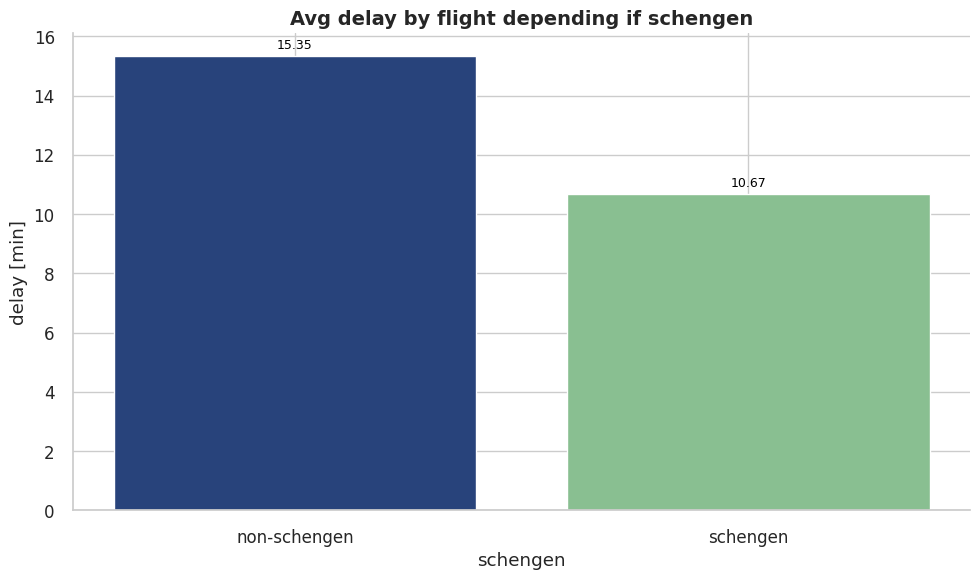

In [12]:
avg_delay_schengen = datos.groupby('schengen')['delay'].mean().reset_index()
display(show_table(avg_delay_schengen, 'delay'))
barplot(avg_delay_schengen, 'schengen', 'delay', 'Avg delay by flight depending if schengen','min').show()

,is_holiday,delay
1,holiday,42.09
0,not_holiday,10.84


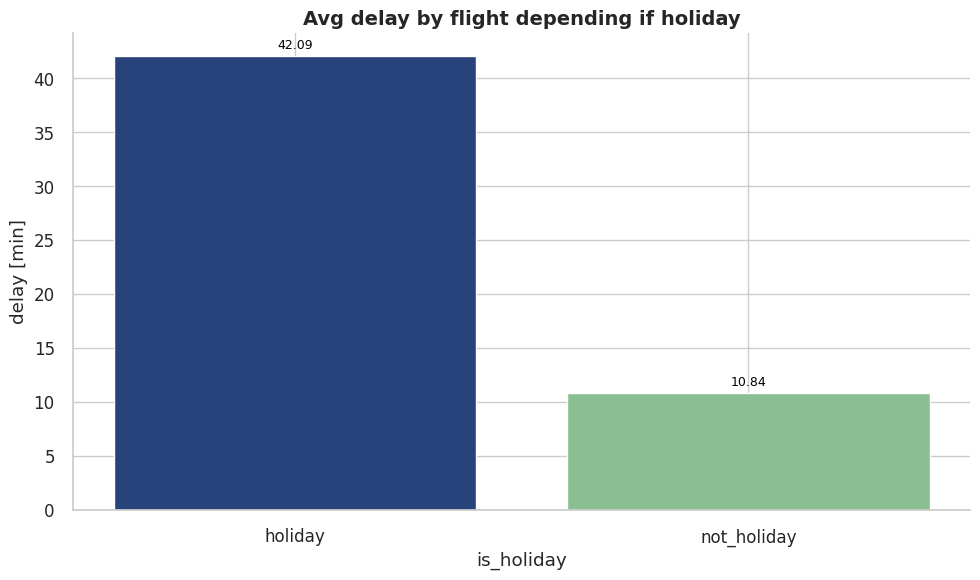

In [13]:
avg_delay_if_holoday = datos.groupby('is_holiday')['delay'].mean().reset_index()
#avg_delay_if_holoday['is_holiday'] = avg_delay_if_holoday['is_holiday'].apply(lambda x: 'holiday' if x else 'not_holiday')
avg_delay_if_holoday['is_holiday'] = avg_delay_if_holoday['is_holiday'].map({True: 'holiday', False: 'not_holiday'})
display(show_table(avg_delay_if_holoday,'delay'))
barplot(avg_delay_if_holoday, 'is_holiday', 'delay', 'Avg delay by flight depending if holiday','min').show()


,aircraft_type,flights
0,Airbus A320,30778
1,Airbus A330,16654
2,Boeing 787,9606
3,Embraer E175,7098
4,Boeing 737,4722
5,Boeing 777,2317


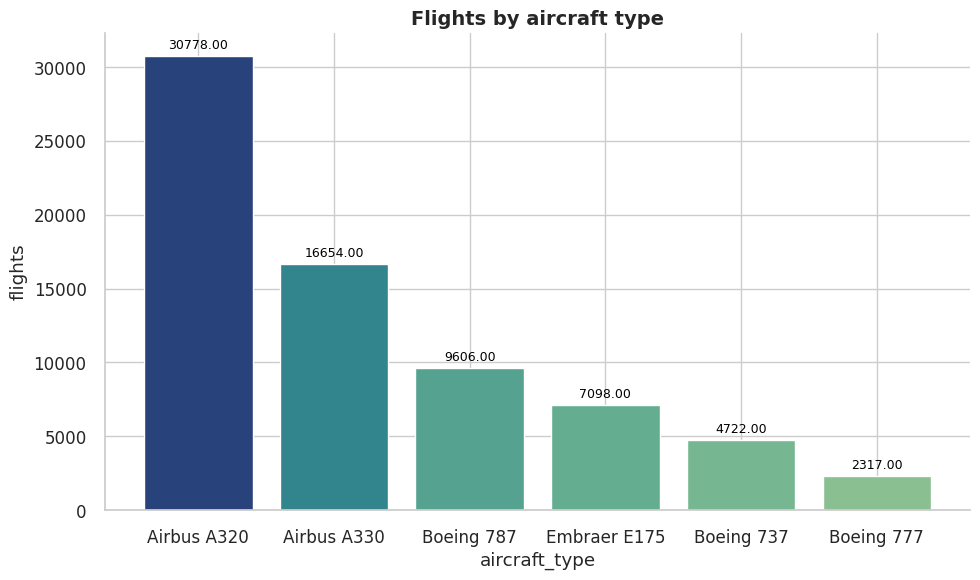

In [14]:
flights_by_aircraft = datos.value_counts('aircraft_type').reset_index()
flights_by_aircraft.rename(columns={'count':'flights'}, inplace=True)
display(show_table(flights_by_aircraft, 'flights'))
barplot(flights_by_aircraft, 'aircraft_type', 'flights', 'Flights by aircraft type').show()

,aircraft_type,delay
0,Airbus A320,21.50
2,Boeing 737,17.10
3,Boeing 777,16.50
4,Boeing 787,13.06
5,Embraer E175,1.21
1,Airbus A330,-1.30


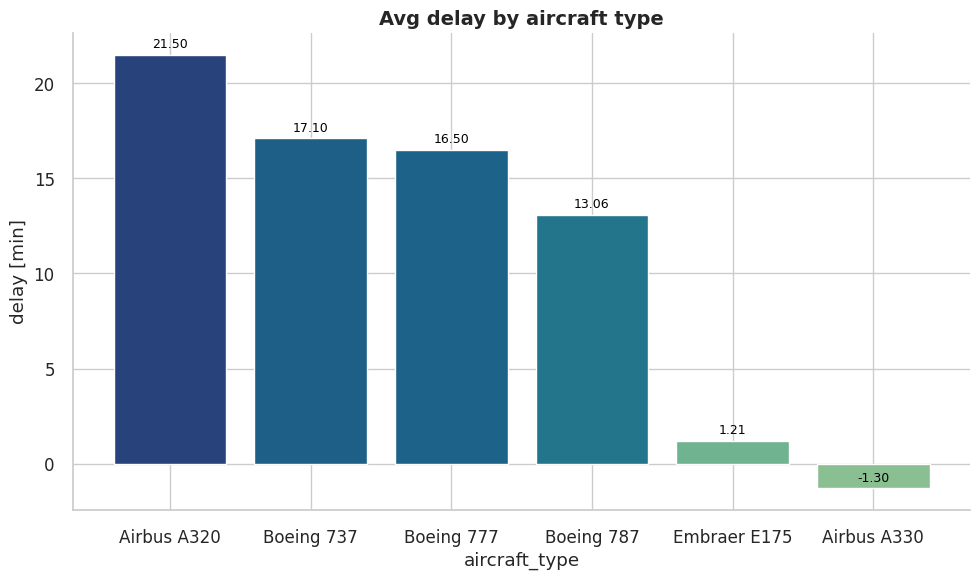

In [15]:
avg_delay_by_aircraft = datos.groupby('aircraft_type')['delay'].mean().reset_index()
display(show_table(avg_delay_by_aircraft, 'delay'))
barplot(avg_delay_by_aircraft, 'aircraft_type', 'delay', 'Avg delay by aircraft type','min').show()

In [16]:
def histplot(df, x, title=None, bins=None, x_unit=None):

    fig, ax = plt.subplots(figsize=(10,6))

    if bins is None:
      # Freedman–Diaconis rule
      IQR = df[x].quantile(0.75) - df[x].quantile(0.25)
      n = len(df)
      bin_width = 2 * IQR / np.power(n, 1/3)
      bins = int((df[x].max() - df[x].min()) / bin_width)

    # color medio de la paleta
    hist_color = CMAP(0.55)
    kde_color = CMAP(0.9)

    sns.histplot(
        data=df,
        x=x,
        bins=bins,
        kde=True,
        color=hist_color,
        edgecolor='white',
        ax=ax
    )

    # cambiar color de la KDE
    if ax.lines:
        ax.lines[0].set_color(kde_color)
        ax.lines[0].set_linewidth(2)

    ax.set_title(title if title else f'Distribution of {x}',
                 fontsize=14,
                 weight='bold')

    ax.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax.set_ylabel("Count")

    sns.despine()
    plt.tight_layout()

    return fig

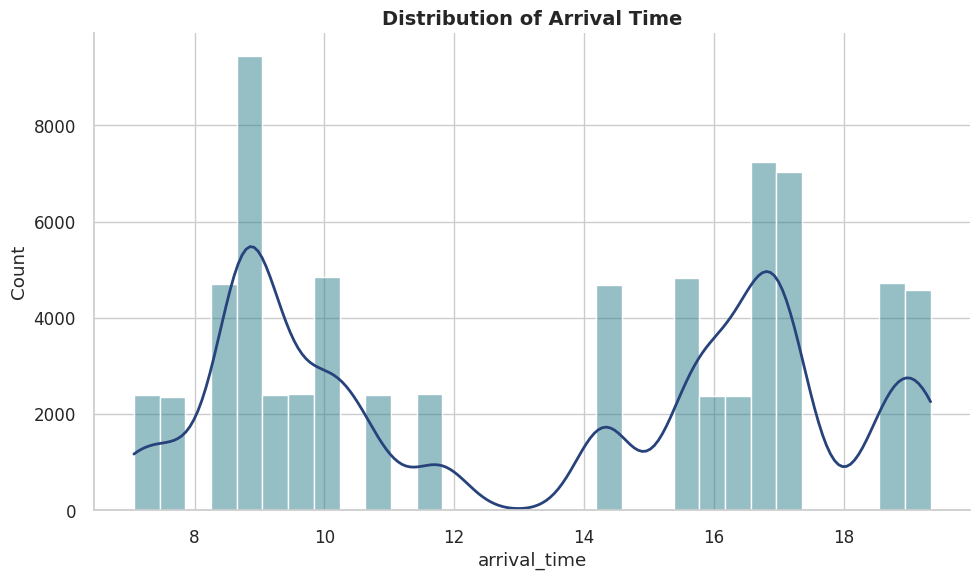

In [17]:
histplot(datos, 'arrival_time', 'Distribution of Arrival Time').show()



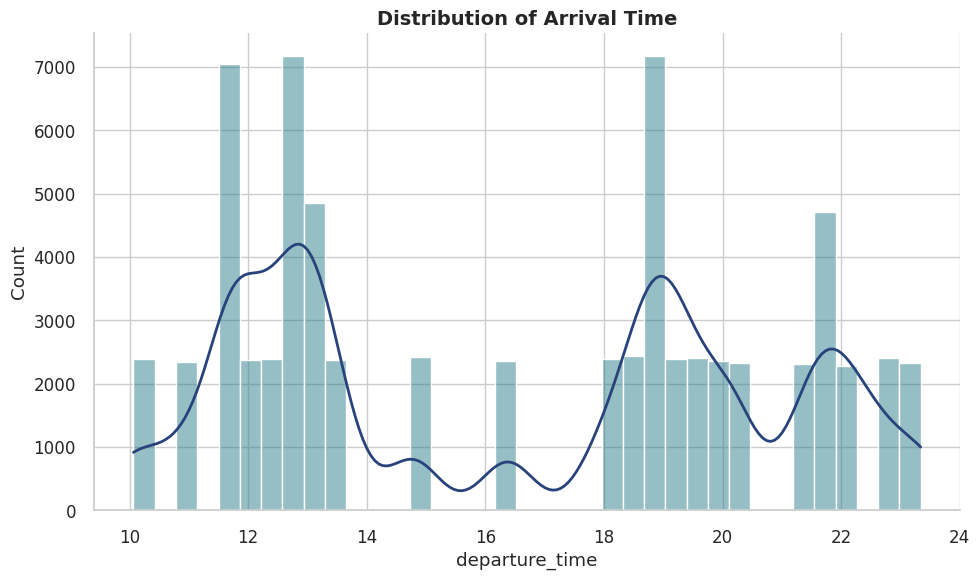

In [18]:
histplot(datos, 'departure_time', 'Distribution of Arrival Time').show()



In [19]:

avg_delay = datos['delay'].mean()
median_delay = datos['delay'].median()
print(f'Average delay: {avg_delay:.2f} min')
print(f'Median delay: {median_delay:.2f} min')

Average delay: 12.55 min
Median delay: 9.74 min


In [20]:
def boxplot(df, x, title=None, x_unit=None):

    fig, ax = plt.subplots(figsize=(10,6))

    box_color = CMAP(0.55)
    edge_color = CMAP(0.9)

    sns.boxplot(
        x=df[x],
        ax=ax,
        color=box_color,
        width=0.4,
        fliersize=3,
        linewidth=1.5
    )

    # estilizar líneas internas del boxplot
    for line in ax.lines:
        line.set_color(edge_color)
        line.set_linewidth(1.5)

    ax.set_title(
        title if title else f'Distribution of {x}',
        fontsize=14,
        weight='bold'
    )

    ax.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax.set_ylabel("")

    sns.despine()
    plt.tight_layout()

    return fig

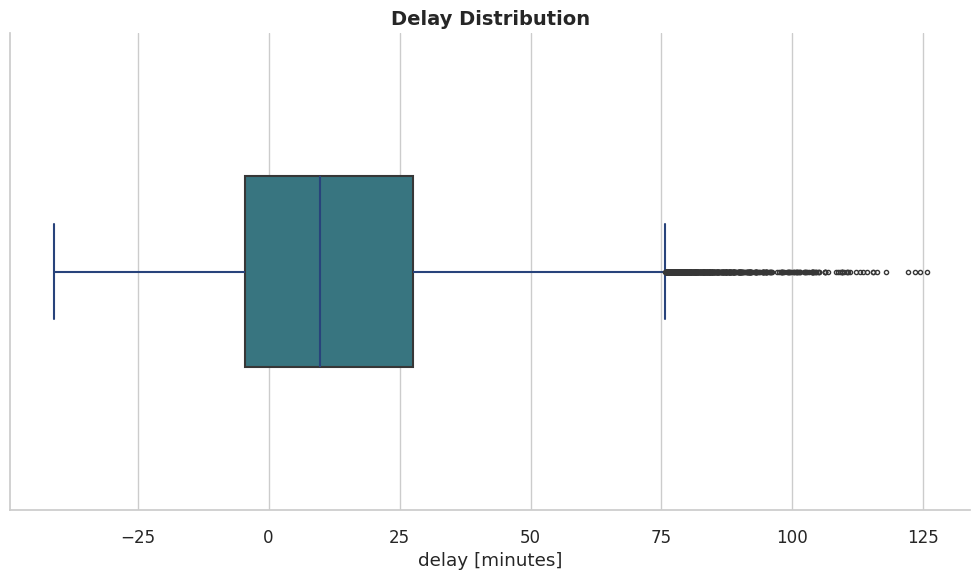

In [21]:
boxplot(datos, 'delay', 'Delay Distribution', 'minutes').show()

In [22]:
def distribution_plot(df, x, title=None, bins=None, x_unit=None):

    data = df[x].dropna()

    # -------- estadísticas --------
    mean_val = data.mean()
    median_val = data.median()

    # -------- bins automáticos (Freedman–Diaconis) --------
    if bins is None:
        q75, q25 = np.percentile(data, [75, 25])
        iqr = q75 - q25
        n = len(data)

        bin_width = 2 * iqr / n**(1/3)

        if bin_width > 0:
            bins = int((data.max() - data.min()) / bin_width)
        else:
            bins = 20

    # -------- colores consistentes --------
    hist_color = CMAP(0.55)
    kde_color = CMAP(0.9)
    box_color = CMAP(0.55)
    edge_color = CMAP(0.9)

    mean_color = CMAP(0.95)
    median_color = CMAP(0.75)

    # -------- figura --------
    fig, (ax_hist, ax_box) = plt.subplots(
        2,
        1,
        figsize=(10,7),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True
    )

    # -------- Histograma --------
    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color=hist_color,
        edgecolor="white",
        ax=ax_hist
    )

    if ax_hist.lines:
        ax_hist.lines[0].set_color(kde_color)
        ax_hist.lines[0].set_linewidth(2)

    # -------- líneas de media y mediana --------
    ax_hist.axvline(mean_val, color=mean_color, linestyle="--", linewidth=2)
    ax_hist.axvline(median_val, color=median_color, linestyle="-", linewidth=2)

    # -------- texto con estadísticas --------
    stats_text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}"
        + (f" {x_unit}" if x_unit else "")
    )

    ax_hist.text(
        0.98,
        0.95,
        stats_text,
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

    ax_hist.set_title(
        title if title else f'Distribution of {x}',
        fontsize=14,
        weight="bold"
    )

    ax_hist.set_ylabel("Count")

    # -------- Boxplot --------
    sns.boxplot(
        x=data,
        ax=ax_box,
        color=box_color,
        width=0.4,
        fliersize=3,
        linewidth=1.5
    )

    for line in ax_box.lines:
        line.set_color(edge_color)
        line.set_linewidth(1.5)

    ax_box.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax_box.set_ylabel("")

    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box)

    plt.tight_layout()

    return fig

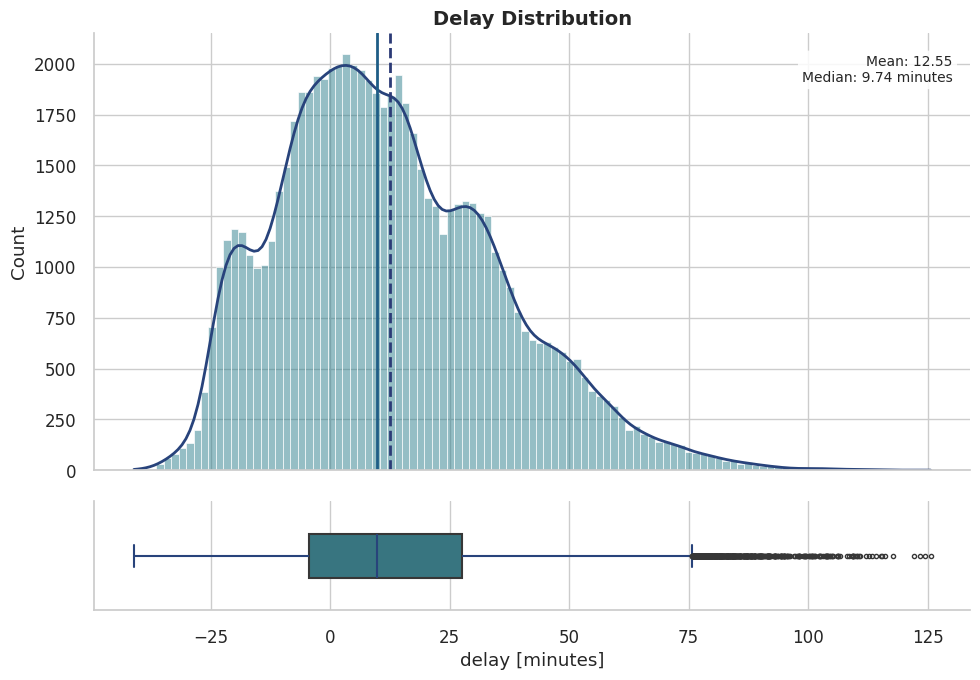

In [23]:
distribution_plot(datos, 'delay', 'Delay Distribution', x_unit='minutes').show()

In [24]:
#GridSearchCV | Hyperparameter Tuning | Machine Learning with Scikit-Learn Python
from sklearn.model_selection import train_test_split,GridSearchCV



¡Estandarización vs. Normalización explicadas claramente!

https://www.youtube.com/watch?v=sxEqtjLC0aM

ROC and AUC, Clearly Explained!
https://www.youtube.com/watch?v=4jRBRDbJemM